# GeoBrain Flow Simulation: Dynamic Well Control

Step-by-Step Simulation with Well Management.

Features:
1. Create custom simulation model
2. Run full simulation
3. Step-by-step simulation with visualization
4. Dynamic well control: Add new wells and shut existing wells during simulation

---

This notebook extends the basic flow simulation with **step-by-step
control** and **dynamic well management**.

During a simulation you can pause, add new wells, shut existing wells, and
resume — exactly as done in real-field development adjustments.

In [1]:
import sys
sys.path.insert(0, '../..')

import json
import os
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

matplotlib.rcParams.update({
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.1,
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'axes.titleweight': 'semibold',
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'legend.framealpha': 0.9,
    'figure.facecolor': 'white',
    'axes.facecolor': '#fafafa',
    'axes.edgecolor': '#cccccc',
    'axes.linewidth': 0.8,
    'grid.color': '#e0e0e0',
    'grid.linewidth': 0.5,
    'lines.linewidth': 1.5,
    'image.cmap': 'viridis',
})

FIGS_DIR = os.path.join('..', 'figs')
os.makedirs(FIGS_DIR, exist_ok=True)

from geobrain.physics.flow import ReservoirModel, FlowPropagator, Well, compute_well_index

# Load PVT data from JSON
_data_path = os.path.join("..", "data", "pvt", "pvt_data.json")
with open(_data_path) as _f:
    _pvt = json.load(_f)
PVDO = _pvt["PVDO"]["data"]
PVTW = _pvt["PVTW"]["data"]
SWOF = _pvt["SWOF"]["data"]

## Helper Functions

`create_well()` and `create_model()` wrap the full well / model setup in a
configuration-driven interface:

- Multiple perforations per well
- BHP or rate-controlled wells (oil / water / liquid)
- Automatic Peaceman well-index computation

In [2]:
def create_well(model, well_cfg, well_type):
    """
    Create a well from configuration dictionary.

    Args:
        model: ReservoirModel instance
        well_cfg: Well configuration dict with keys:
            - name: Well name (str)
            - perforation: List of (i, j, k) tuples (1-based indices)
            - radius: Well radius in ft (default: 0.5)
            - skin: Skin factor (default: 0.0)
            - mode: Control mode 'bhp' or 'rate' (default: 'bhp')
            - target: Control target value
            - phase: Rate phase 'OIL', 'WAT', 'LIQ' (for rate mode)
            - bhp_limit: BHP limit for rate control
        well_type: 'PROD' for producer, 'INJ' for injector

    Returns:
        Configured Well instance
    """
    well = Well(
        name=well_cfg['name'],
        well_type=well_type,
        device=model.device,
        dtype=model.dtype
    )

    for perf in well_cfg['perforation']:
        i, j, k = perf[0] - 1, perf[1] - 1, perf[2] - 1
        cell_idx = model.grid.ijk_to_global(i, j, k)

        rw = well_cfg.get('radius', 0.5)
        skin = well_cfg.get('skin', 0.0)
        dx = float(model.grid.dx[i])
        dy = float(model.grid.dy[j])
        dz = float(model.grid.dz[k])
        kx = float(model.rock.perm_x[cell_idx])
        ky = float(model.rock.perm_y[cell_idx])

        wi = compute_well_index(kx, ky, dx, dy, dz, rw, skin)
        well.add_perforation(cell_idx=cell_idx, wi=wi, depth=model.grid.depth[cell_idx].item())

    mode = well_cfg.get('mode', 'bhp').upper()
    target = well_cfg['target']

    if mode == 'BHP':
        well.set_control('BHP', target=target)
    else:
        phase = well_cfg.get('phase', 'LIQ')
        bhp_limit = well_cfg.get('bhp_limit', None)
        well.set_control('RATE', target=target, phase=phase, bhp_limit=bhp_limit)

    return well


def create_model(options):
    """
    Create a ReservoirModel from options dictionary.

    Args:
        options: Configuration dict with keys:
            - nx, ny, nz: Grid dimensions
            - dx, dy, dz: Cell sizes (ft)
            - d: Top depth (ft)
            - perm, poro: Rock properties
            - po, sw: Initial pressure and water saturation
            - PVDO, PVTW, SWOF: PVT tables
            - producers, injectors: Well configuration lists

    Returns:
        Initialized ReservoirModel
    """
    model = ReservoirModel(nx=options['nx'], ny=options['ny'], nz=options['nz'])

    model.set_grid(
        dx=options['dx'],
        dy=options['dy'],
        dz=options['dz'],
        top_depth=options.get('d', 0.0)
    )
    model.set_rock(perm=options['perm'], poro=options['poro'])
    model.set_pvt(pvdo=options['PVDO'], pvtw=options['PVTW'])
    model.set_relperm(swof=options['SWOF'])

    for prod_cfg in options.get('producers', []):
        model.add_well(create_well(model, prod_cfg, 'PROD'))
    for inj_cfg in options.get('injectors', []):
        model.add_well(create_well(model, inj_cfg, 'INJ'))

    model.initialize(po=options['po'], sw=options['sw'])
    return model

## Plotting Functions (direct code — custom layouts with imshow origin='lower')

In [3]:
def plot_state_maps(propagator, figsize=(10, 4)):
    """
    Plot pressure and saturation maps at current time.

    Args:
        propagator: FlowPropagator instance with simulation history
        figsize: Figure size tuple (width, height)

    Returns:
        matplotlib Figure object
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize)
    t = propagator.t_current

    po = propagator.pressure_history[t].cpu().numpy()
    sw = propagator.saturation_history[t].cpu().numpy()

    po_2d = po.reshape(propagator.nx, propagator.ny, order='F')
    sw_2d = sw.reshape(propagator.nx, propagator.ny, order='F')

    im1 = ax1.imshow(po_2d.T, cmap='RdYlBu_r', origin='lower')
    ax1.set_title(f'Pressure (t={t:.0f} days)')
    ax1.set_xlabel('X')
    ax1.set_ylabel('Y')
    plt.colorbar(im1, ax=ax1, label='psi')

    im2 = ax2.imshow(sw_2d.T, cmap='YlGnBu', origin='lower')
    ax2.set_title(f'Water Saturation (t={t:.0f} days)')
    ax2.set_xlabel('X')
    ax2.set_ylabel('Y')
    plt.colorbar(im2, ax=ax2)

    plt.tight_layout()
    return fig


def plot_step_results(propagator, t_max=1000, figsize=(14, 4)):
    """
    Plot state maps and production curves for P1.

    Args:
        propagator: FlowPropagator instance with simulation history
        t_max: Maximum time for x-axis scaling (days)
        figsize: Figure size tuple (width, height)

    Returns:
        matplotlib Figure object
    """
    fig, axes = plt.subplots(1, 4, figsize=figsize)
    t = propagator.t_current

    po = propagator.pressure_history[t].cpu().numpy()
    sw = propagator.saturation_history[t].cpu().numpy()

    po_2d = po.reshape(propagator.nx, propagator.ny, order='F')
    sw_2d = sw.reshape(propagator.nx, propagator.ny, order='F')

    im1 = axes[0].imshow(po_2d.T, cmap='RdYlBu_r', origin='lower')
    axes[0].set_title('Pressure')
    plt.colorbar(im1, ax=axes[0])

    im2 = axes[1].imshow(sw_2d.T, cmap='YlGnBu', origin='lower')
    axes[1].set_title('Water Saturation')
    plt.colorbar(im2, ax=axes[1])

    # Production curves
    data = propagator.get_well_data('P1')
    t_arr = np.array(data['time'])
    qo = np.array(data['qo'])
    qw = np.array(data['qw'])

    axes[2].fill_between(t_arr, qo, alpha=0.15, color='#2ca02c')
    axes[2].plot(t_arr, qo, '-', color='#2ca02c', linewidth=1.5)
    axes[2].set_xlabel('Time (Day)')
    axes[2].set_ylabel('Oil Rate')
    axes[2].set_xlim([0, t_max])
    axes[2].set_ylim([0, 200])
    axes[2].grid(True, alpha=0.3, linestyle='--')

    axes[3].fill_between(t_arr, qw, alpha=0.15, color='#1f77b4')
    axes[3].plot(t_arr, qw, '-', color='#1f77b4', linewidth=1.5)
    axes[3].set_xlabel('Time (Day)')
    axes[3].set_ylabel('Water Rate')
    axes[3].set_xlim([0, t_max])
    axes[3].set_ylim([0, 200])
    axes[3].grid(True, alpha=0.3, linestyle='--')

    fig.suptitle(f't = {t:.0f} days', fontsize=12)
    plt.tight_layout()
    return fig

## Model Configuration

30 × 15 grid, 20 mD permeability (moderate), with one producer (P1) and
one injector (I1).  Simulation spans 1 825 days (5 years).

In [4]:
OPTIONS = {
    # Grid
    'nx': 30, 'ny': 15, 'nz': 1,
    'dx': 50.0, 'dy': 50.0, 'dz': 10.0,
    'd': 3000.0,  # Top depth (ft)

    # Rock
    'perm': 20.0,   # mD
    'poro': 0.2,

    # Initial conditions
    'po': 6000.0,   # psi
    'sw': 0.1,

    # PVT data
    'PVDO': PVDO,
    'PVTW': PVTW,
    'SWOF': SWOF,

    # Wells
    'producers': [
        {'name': 'P1', 'perforation': [(5, 2, 1)], 'radius': 0.5,
         'mode': 'bhp', 'target': 5000.0}
    ],
    'injectors': [
        {'name': 'I1', 'perforation': [(25, 13, 1)], 'radius': 0.5,
         'mode': 'bhp', 'target': 7000.0}
    ],

    # Time stepping
    'dt_init': 0.1,
    'dt_max': 100.0,
    't_end': 1825.0,

    # Solver
    'newton_tol': 1e-3,
    'max_newton_iter': 10,
}

print(f"Grid: {OPTIONS['nx']} x {OPTIONS['ny']} x {OPTIONS['nz']}")
print(f"Permeability: {OPTIONS['perm']} mD")
print(f"Producer P1 at (5, 2): BHP = {OPTIONS['producers'][0]['target']} psi")
print(f"Injector I1 at (25, 13): BHP = {OPTIONS['injectors'][0]['target']} psi")

Grid: 30 x 15 x 1
Permeability: 20.0 mD
Producer P1 at (5, 2): BHP = 5000.0 psi
Injector I1 at (25, 13): BHP = 7000.0 psi


## Part 1 — Full Simulation

Demonstrates the basic API: `time_step()` for a single step, `run_to()` for
batch execution to a target time.  Production curves and state maps are
plotted at the end.


--- Part 1: Full Simulation ---
Model created: 450 cells
After 1 step: t = 0.100 days
Running to t = 1825.0 days...
Completed: t = 1825.0 days


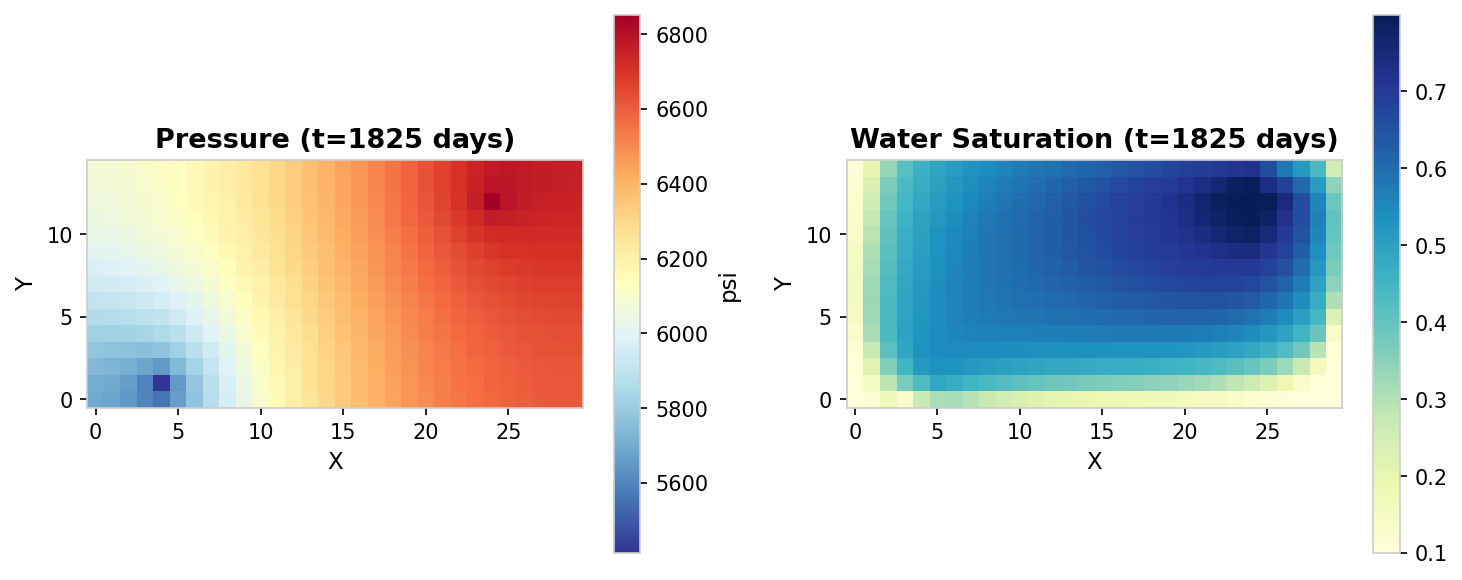

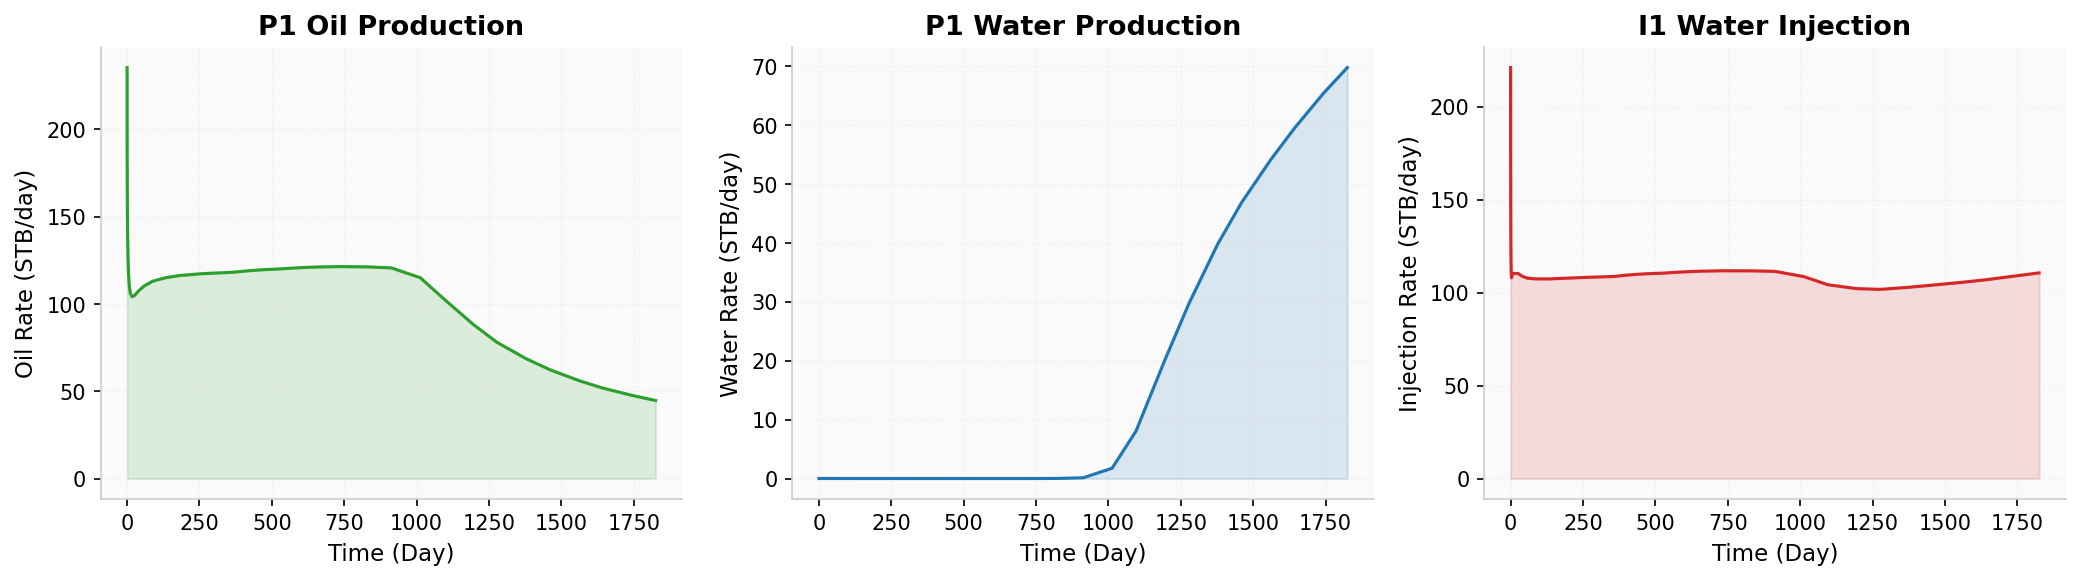

In [5]:
print("\n--- Part 1: Full Simulation ---")

# Create model
model = create_model(OPTIONS)
print(f"Model created: {model.nc} cells")

# Create propagator
propagator = FlowPropagator(
    model,
    dt_init=OPTIONS['dt_init'],
    dt_max=OPTIONS['dt_max'],
    max_newton_iter=OPTIONS['max_newton_iter'],
    newton_tol=OPTIONS['newton_tol']
)

# Single time step
propagator.time_step()
print(f"After 1 step: t = {propagator.t_current:.3f} days")

# Run to end
print(f"Running to t = {OPTIONS['t_end']} days...")
propagator.run_to(t_end=OPTIONS['t_end'])
print(f"Completed: t = {propagator.t_current:.1f} days")

# Plot final state
plot_state_maps(propagator)
plt.savefig(os.path.join(FIGS_DIR, '11_full_sim_state_maps.png'))
plt.show()

# Plot production curves
data_p1 = propagator.get_well_data('P1')
data_i1 = propagator.get_well_data('I1')

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

t = np.array(data_p1['time'])
t_plot = t[1:]
qo_plot = np.array(data_p1['qo'][1:])
qw_plot = np.array(data_p1['qw'][1:])
qi_plot = -np.array(data_i1['qw'][1:])

axes[0].fill_between(t_plot, qo_plot, alpha=0.15, color='#2ca02c')
axes[0].plot(t_plot, qo_plot, '-', color='#2ca02c', linewidth=1.5)
axes[0].set_xlabel('Time (Day)')
axes[0].set_ylabel('Oil Rate (STB/day)')
axes[0].set_title('P1 Oil Production')
axes[0].grid(True, alpha=0.3, linestyle='--')
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

axes[1].fill_between(t_plot, qw_plot, alpha=0.15, color='#1f77b4')
axes[1].plot(t_plot, qw_plot, '-', color='#1f77b4', linewidth=1.5)
axes[1].set_xlabel('Time (Day)')
axes[1].set_ylabel('Water Rate (STB/day)')
axes[1].set_title('P1 Water Production')
axes[1].grid(True, alpha=0.3, linestyle='--')
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

axes[2].fill_between(t_plot, qi_plot, alpha=0.15, color='#d62728')
axes[2].plot(t_plot, qi_plot, '-', color='#d62728', linewidth=1.5)
axes[2].set_xlabel('Time (Day)')
axes[2].set_ylabel('Injection Rate (STB/day)')
axes[2].set_title('I1 Water Injection')
axes[2].grid(True, alpha=0.3, linestyle='--')
axes[2].spines['top'].set_visible(False)
axes[2].spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(os.path.join(FIGS_DIR, '11_full_sim_production.png'))
plt.show()

## Part 2 — Step-by-Step Simulation

`step_to(t)` advances the simulation to an exact target time.  By calling
it in a loop (every 100 days), you can inspect intermediate states and make
decisions before continuing.


--- Part 2: Step-by-Step Simulation ---
Created new model for step-by-step simulation
Stepping from t=100 to t=500...
  t = 100 days
  t = 200 days
  t = 300 days
  t = 400 days
  t = 500 days


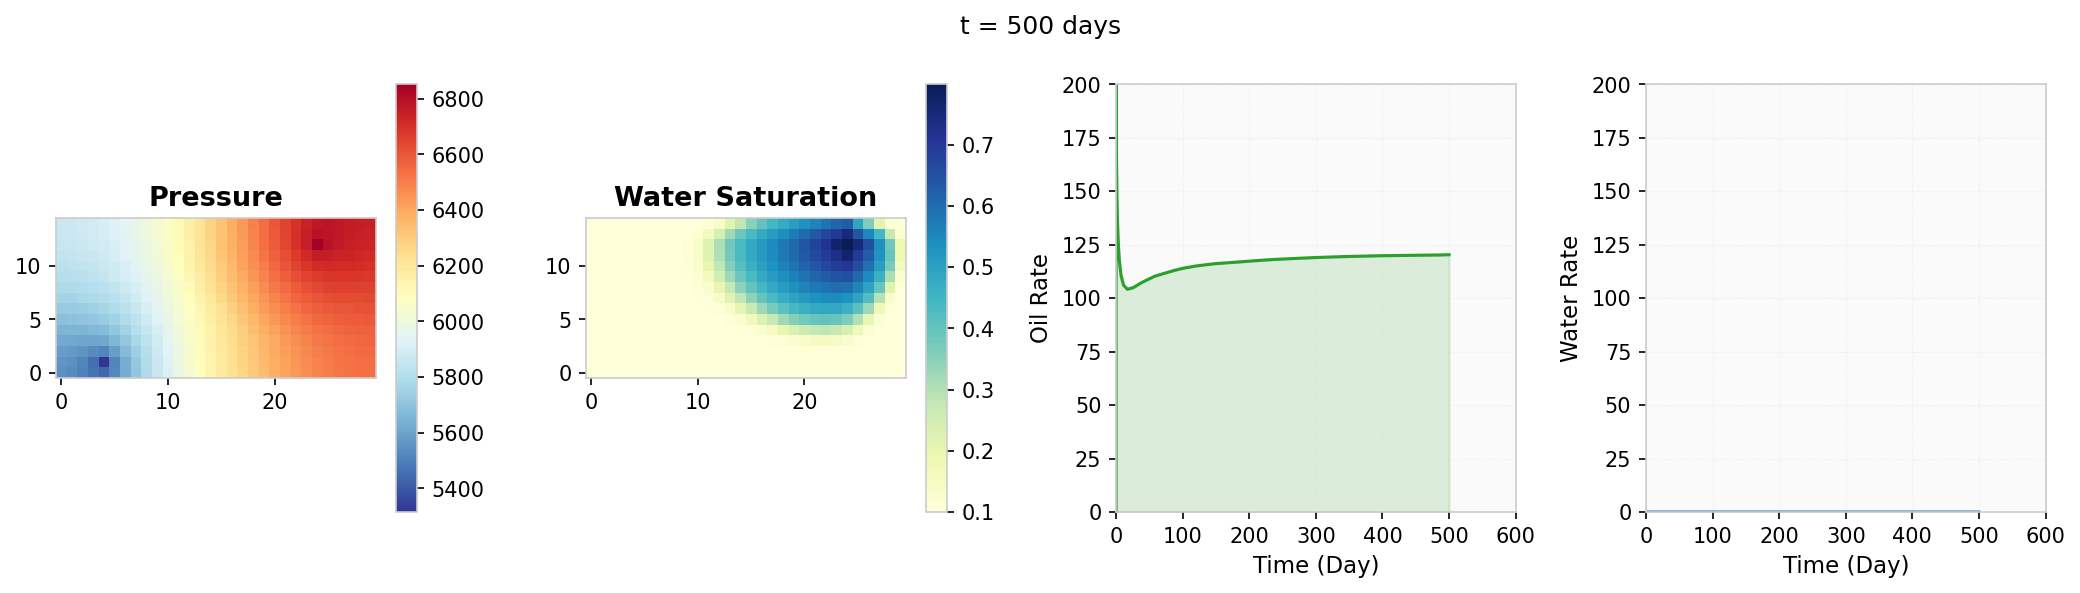

In [6]:
print("\n--- Part 2: Step-by-Step Simulation ---")

# Create new model and propagator
model2 = create_model(OPTIONS)
propagator2 = FlowPropagator(
    model2,
    dt_init=OPTIONS['dt_init'],
    dt_max=OPTIONS['dt_max'],
    max_newton_iter=OPTIONS['max_newton_iter'],
    newton_tol=OPTIONS['newton_tol']
)

print("Created new model for step-by-step simulation")

# Step from t=100 to t=500
print("Stepping from t=100 to t=500...")

for t_target in range(100, 501, 100):
    propagator2.step_to(float(t_target))
    print(f"  t = {propagator2.t_current:.0f} days")

plot_step_results(propagator2, t_max=600)
plt.savefig(os.path.join(FIGS_DIR, '11_step_sim_t500.png'))
plt.show()

## Part 3 — Dynamic Well Control

At **t = 500 days** we modify the well configuration:

| Action | Details |
|--------|---------|
| **Add injector I2** | Location (12, 10), BHP = 6 549 psi |
| **Shut injector I1** | Stops injection at the original location |

The simulation then continues to t = 1 000 days.  Observe how pressure and
saturation fields respond to the redirected injection.


--- Part 3: Dynamic Well Control ---
Current time: t = 500 days
Current wells: ['P1', 'I1']
Added I2 at t = 500 days
Shut I1 at t = 500 days

Continuing simulation with new well configuration...
  t = 600 days
  t = 700 days
  t = 800 days
  t = 900 days
  t = 1000 days


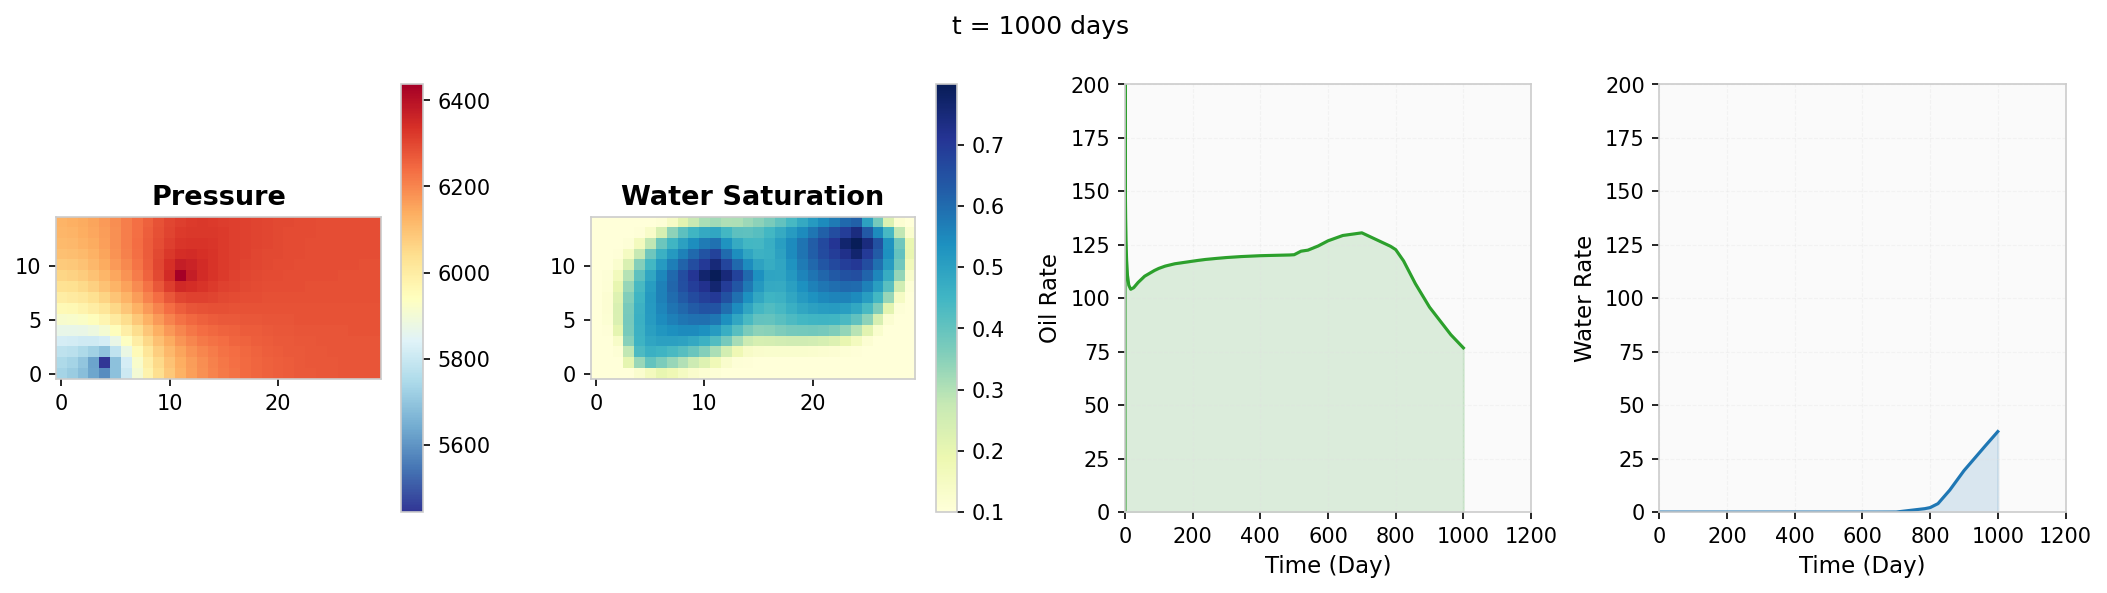

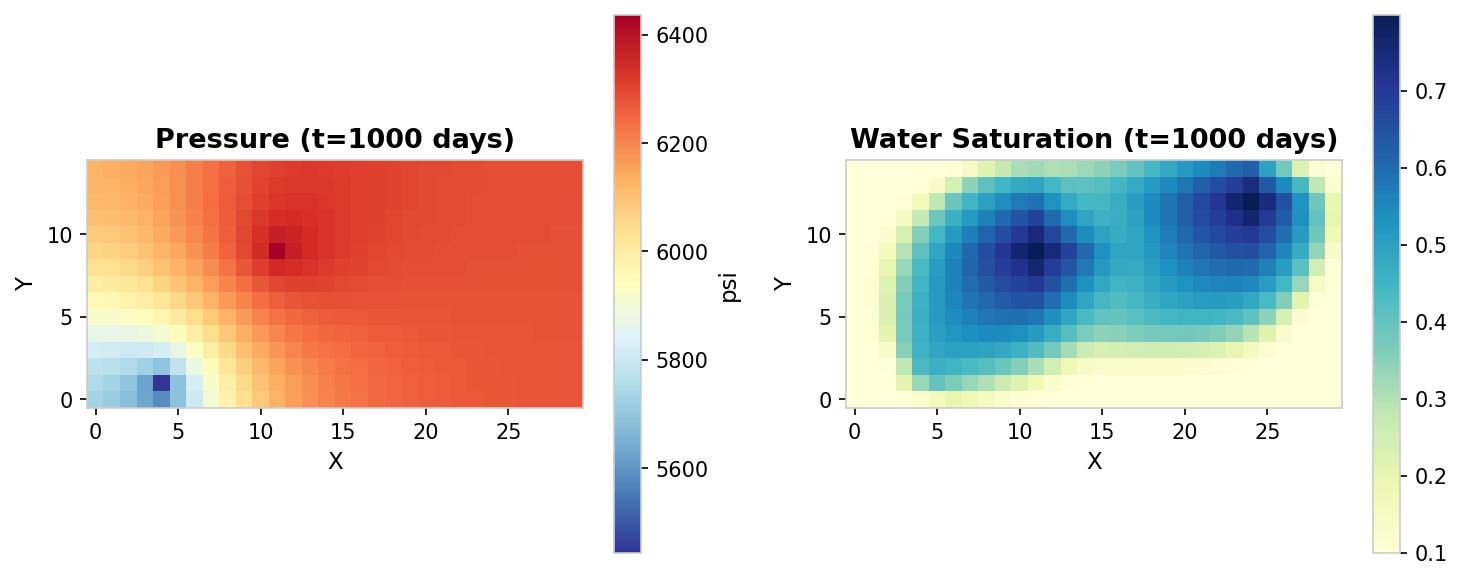

In [7]:
print("\n--- Part 3: Dynamic Well Control ---")

# At t=500 days, we will:
# 1. Add a new injector I2
# 2. Shut the existing injector I1

print(f"Current time: t = {propagator2.t_current:.0f} days")
print(f"Current wells: {list(propagator2.model.wells.wells.keys())}")

# Add new injector I2
propagator2.add_well('INJ', {
    'name': 'I2',
    'perforation': [(12, 10, 1)],
    'radius': 1.0,
    'mode': 'bhp',
    'target': 6548.8
})
print(f"Added I2 at t = {propagator2.t_current:.0f} days")

# Shut well I1
propagator2.shut_well('I1')
print(f"Shut I1 at t = {propagator2.t_current:.0f} days")

# Continue simulation from t=600 to t=1000
print("\nContinuing simulation with new well configuration...")

for t_target in range(600, 1001, 100):
    propagator2.step_to(float(t_target))
    print(f"  t = {propagator2.t_current:.0f} days")

plot_step_results(propagator2, t_max=1200)
plt.savefig(os.path.join(FIGS_DIR, '11_dynamic_wells_t1000.png'))
plt.show()

# Final state
plot_state_maps(propagator2)
plt.savefig(os.path.join(FIGS_DIR, '11_dynamic_wells_final_state.png'))
plt.show()

## Part 4 — Animation

Animated evolution with well-status indicators:

- I1 marker fades when shut (α = 0.3)
- I2 marker appears at t = 500 days
- Key snapshots: initial → before change → after change → final


--- Part 4: Animation — Dynamic Well Control ---
History snapshots: 11 time steps
Time range: 0 - 1000 days
Animation saved to flow_dynamic_wells.gif


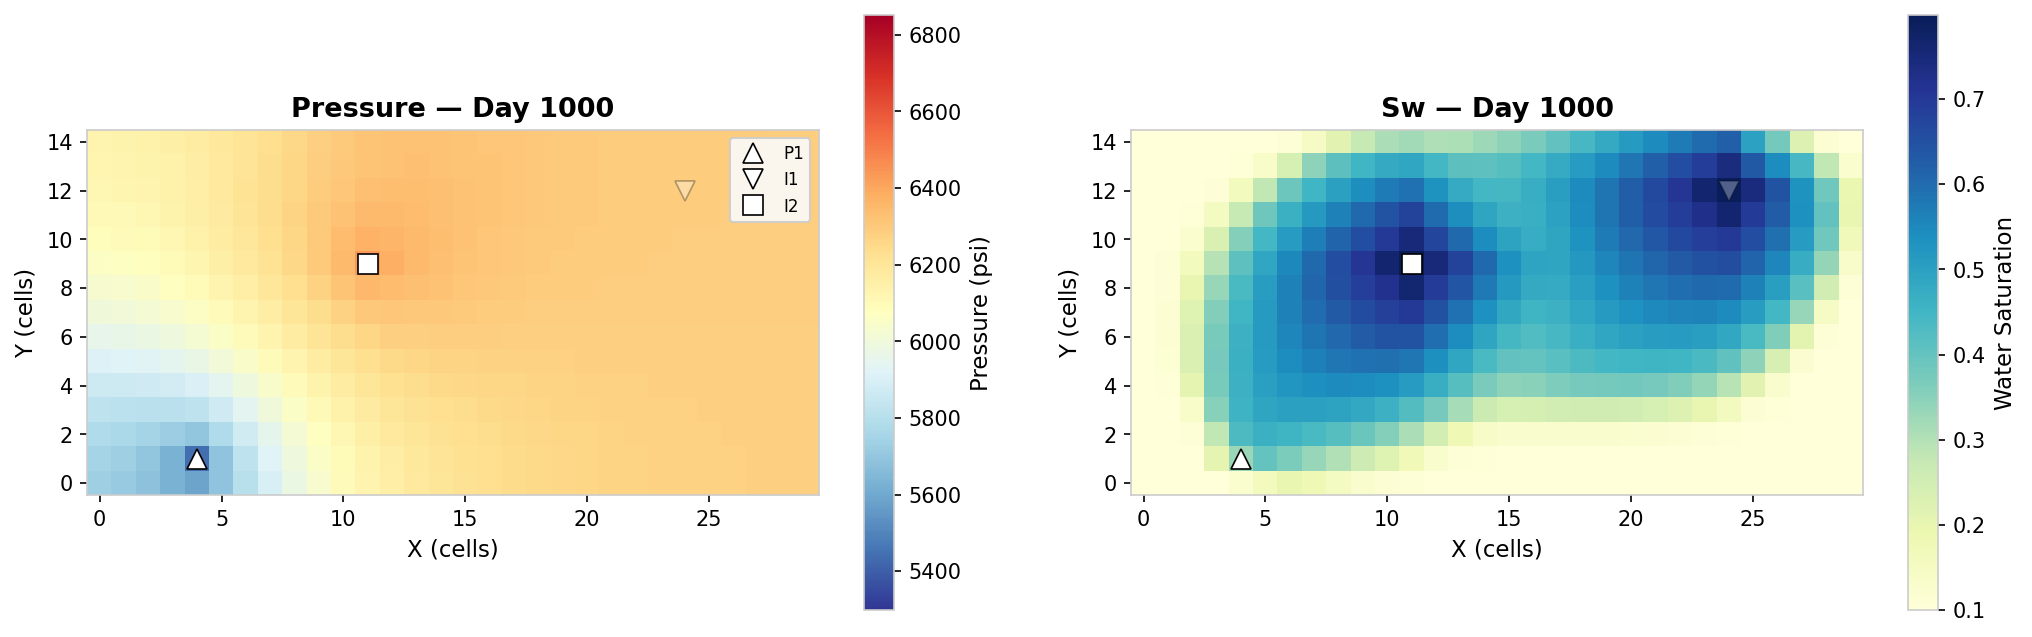

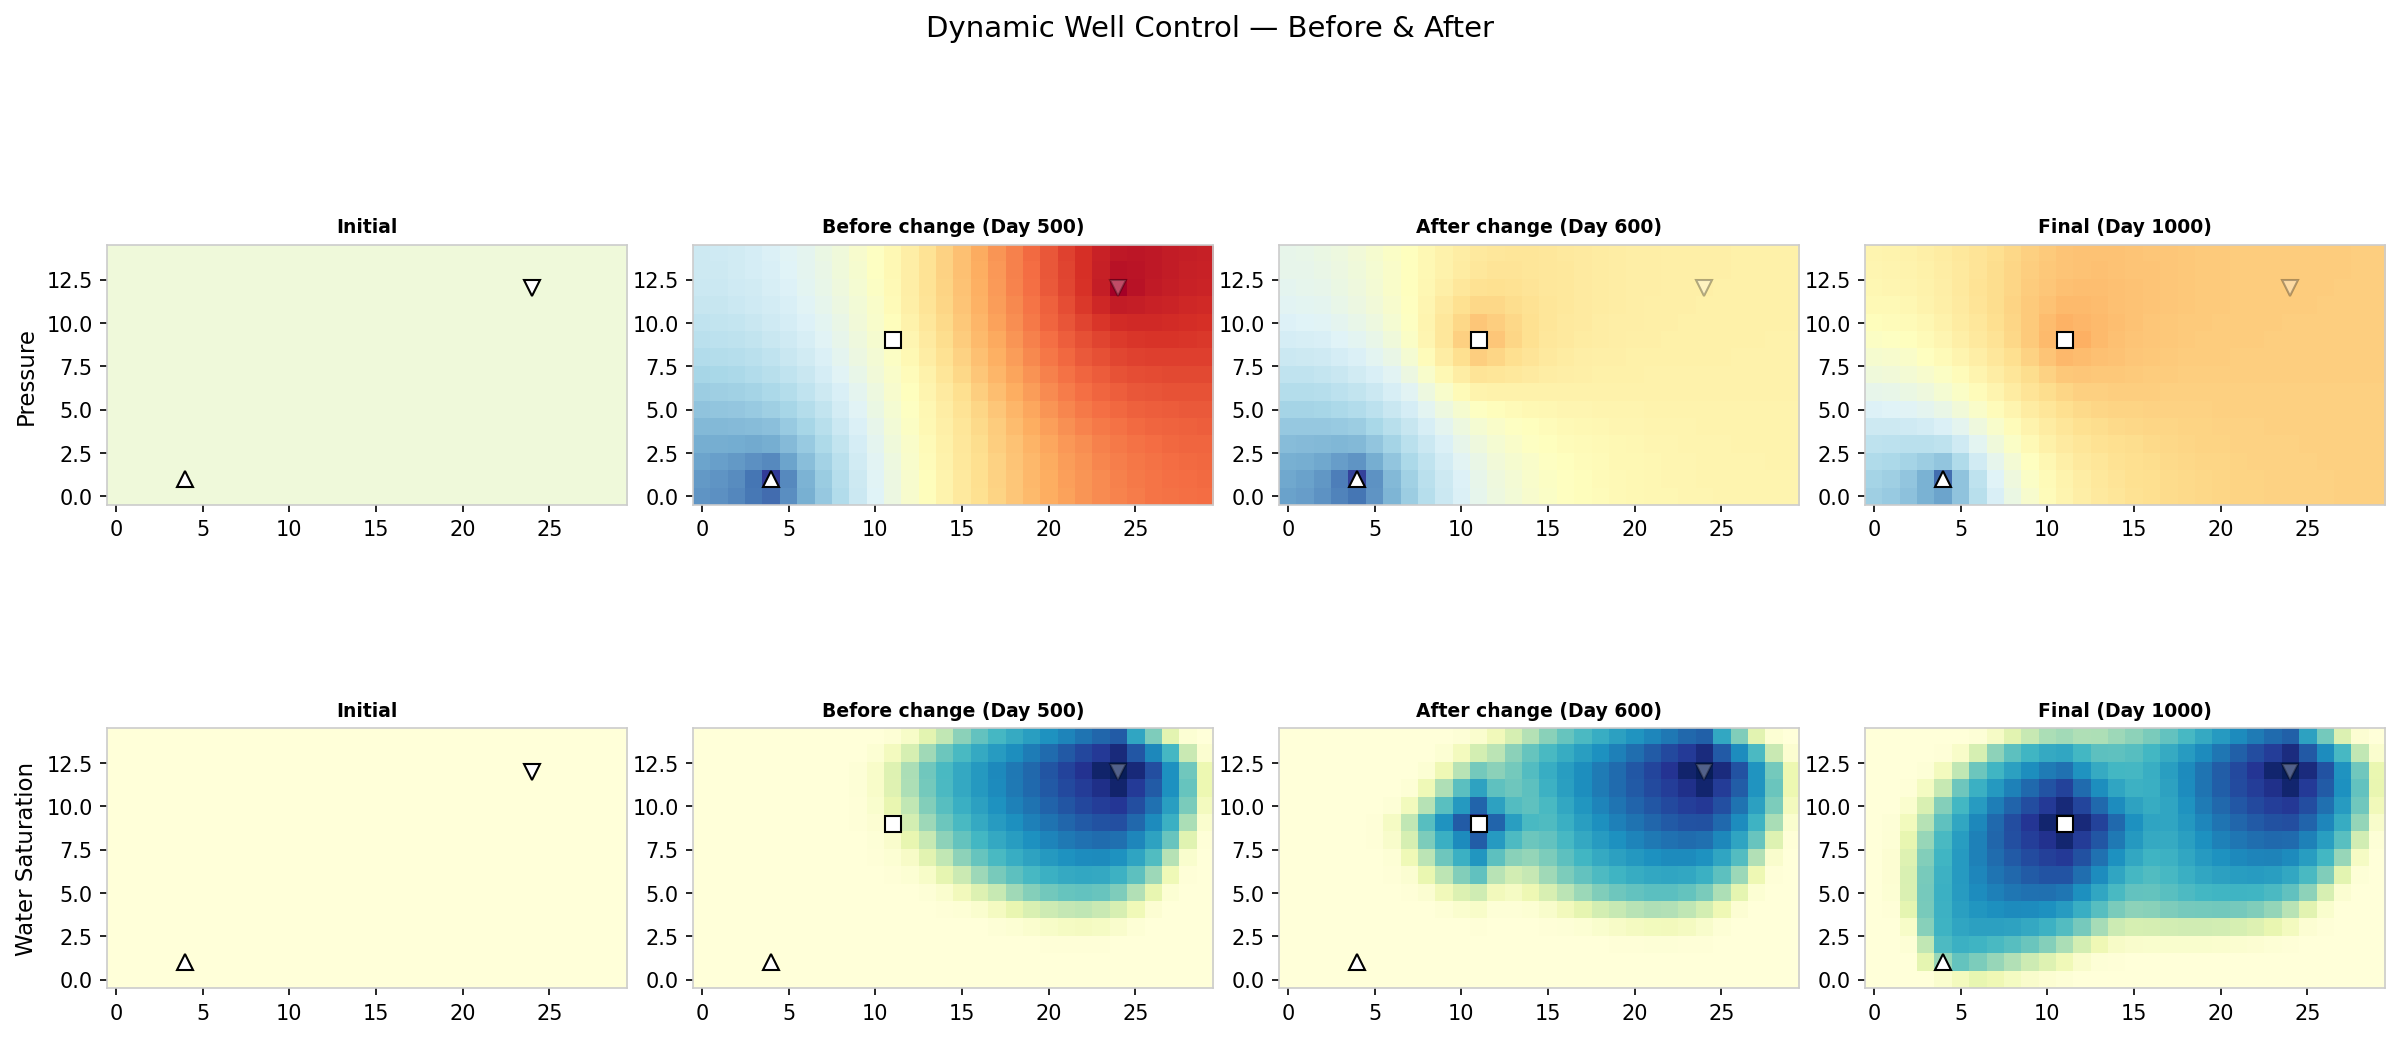

In [8]:
print("\n--- Part 4: Animation — Dynamic Well Control ---")

from matplotlib.animation import FuncAnimation, PillowWriter

# Collect all history snapshots from propagator2
hist_times = sorted(propagator2.pressure_history.keys())
n_frames = len(hist_times)
print(f"History snapshots: {n_frames} time steps")
print(f"Time range: {hist_times[0]:.0f} - {hist_times[-1]:.0f} days")

nx, ny = propagator2.nx, propagator2.ny

po_all = np.array([
    propagator2.pressure_history[t].cpu().numpy().reshape(nx, ny, order='F')
    for t in hist_times
])
sw_all = np.array([
    propagator2.saturation_history[t].cpu().numpy().reshape(nx, ny, order='F')
    for t in hist_times
])

# Global color ranges
po_min, po_max = po_all.min(), po_all.max()
sw_min, sw_max = sw_all.min(), sw_all.max()

# Well positions (0-based cell indices)
# P1 at (5, 2), I1 at (25, 13), I2 at (12, 10) — from OPTIONS
p1_x, p1_y = 5 - 1, 2 - 1
i1_x, i1_y = 25 - 1, 13 - 1
i2_x, i2_y = 12 - 1, 10 - 1

# Event time: I1 shut and I2 added at t=500
t_event = 500.0

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

im1 = ax1.imshow(po_all[0].T, cmap='RdYlBu_r', origin='lower',
                  vmin=po_min, vmax=po_max)
ax1.plot(p1_x, p1_y, 'w^', markersize=10, markeredgecolor='k',
         markeredgewidth=0.8, label='P1')
mk_i1, = ax1.plot(i1_x, i1_y, 'wv', markersize=10, markeredgecolor='k',
                   markeredgewidth=0.8, label='I1')
mk_i2, = ax1.plot([], [], 'ws', markersize=10, markeredgecolor='k',
                   markeredgewidth=0.8, label='I2')
ax1.legend(loc='upper right', fontsize=8)
ax1.set_xlabel('X (cells)')
ax1.set_ylabel('Y (cells)')
plt.colorbar(im1, ax=ax1, label='Pressure (psi)', shrink=0.85)
title1 = ax1.set_title(f'Pressure — Day {hist_times[0]:.0f}')

im2 = ax2.imshow(sw_all[0].T, cmap='YlGnBu', origin='lower',
                  vmin=sw_min, vmax=sw_max)
ax2.plot(p1_x, p1_y, 'w^', markersize=10, markeredgecolor='k',
         markeredgewidth=0.8)
mk2_i1, = ax2.plot(i1_x, i1_y, 'wv', markersize=10, markeredgecolor='k',
                    markeredgewidth=0.8)
mk2_i2, = ax2.plot([], [], 'ws', markersize=10, markeredgecolor='k',
                    markeredgewidth=0.8)
ax2.set_xlabel('X (cells)')
ax2.set_ylabel('Y (cells)')
plt.colorbar(im2, ax=ax2, label='Water Saturation', shrink=0.85)
title2 = ax2.set_title(f'Sw — Day {hist_times[0]:.0f}')

plt.tight_layout()

def update_anim(frame):
    t_now = hist_times[frame]
    im1.set_data(po_all[frame].T)
    title1.set_text(f'Pressure — Day {t_now:.0f}')
    im2.set_data(sw_all[frame].T)
    title2.set_text(f'Sw — Day {t_now:.0f}')

    # Show/hide wells based on event time
    if t_now >= t_event:
        # I1 shut (dim marker), I2 active
        mk_i1.set_alpha(0.3)
        mk2_i1.set_alpha(0.3)
        mk_i2.set_data([i2_x], [i2_y])
        mk2_i2.set_data([i2_x], [i2_y])
    else:
        mk_i1.set_alpha(1.0)
        mk2_i1.set_alpha(1.0)
        mk_i2.set_data([], [])
        mk2_i2.set_data([], [])

    return [im1, im2, title1, title2, mk_i1, mk2_i1, mk_i2, mk2_i2]

anim = FuncAnimation(fig, update_anim, frames=n_frames, interval=200, blit=True)

gif_path = "flow_dynamic_wells.gif"
anim.save(gif_path, writer=PillowWriter(fps=5))
print(f"Animation saved to {gif_path}")
plt.show()

# Key snapshots: before and after well change
before_idx = max(i for i, t in enumerate(hist_times) if t <= t_event)
after_idx = min(i for i, t in enumerate(hist_times) if t > t_event)

key_idx = [0, before_idx, after_idx, n_frames - 1]
labels = ['Initial', f'Before change (Day {hist_times[before_idx]:.0f})',
          f'After change (Day {hist_times[after_idx]:.0f})',
          f'Final (Day {hist_times[-1]:.0f})']

fig, axes = plt.subplots(2, len(key_idx), figsize=(4 * len(key_idx), 8))

for col, (idx, lbl) in enumerate(zip(key_idx, labels)):
    t_now = hist_times[idx]

    # Pressure row
    axes[0, col].imshow(po_all[idx].T, cmap='RdYlBu_r', origin='lower',
                        vmin=po_min, vmax=po_max)
    axes[0, col].plot(p1_x, p1_y, 'w^', markersize=8, markeredgecolor='k')
    if t_now < t_event:
        axes[0, col].plot(i1_x, i1_y, 'wv', markersize=8, markeredgecolor='k')
    else:
        axes[0, col].plot(i1_x, i1_y, 'wv', markersize=8, markeredgecolor='k',
                          alpha=0.3)
        axes[0, col].plot(i2_x, i2_y, 'ws', markersize=8, markeredgecolor='k')
    axes[0, col].set_title(lbl, fontsize=9)
    if col == 0:
        axes[0, col].set_ylabel('Pressure')

    # Saturation row
    axes[1, col].imshow(sw_all[idx].T, cmap='YlGnBu', origin='lower',
                        vmin=sw_min, vmax=sw_max)
    axes[1, col].plot(p1_x, p1_y, 'w^', markersize=8, markeredgecolor='k')
    if t_now < t_event:
        axes[1, col].plot(i1_x, i1_y, 'wv', markersize=8, markeredgecolor='k')
    else:
        axes[1, col].plot(i1_x, i1_y, 'wv', markersize=8, markeredgecolor='k',
                          alpha=0.3)
        axes[1, col].plot(i2_x, i2_y, 'ws', markersize=8, markeredgecolor='k')
    axes[1, col].set_title(lbl, fontsize=9)
    if col == 0:
        axes[1, col].set_ylabel('Water Saturation')

plt.suptitle('Dynamic Well Control — Before & After', fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(FIGS_DIR, '11_dynamic_wells_snapshots.png'))
plt.show()